[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Dataset Sample:
      label                                            message
5014      0  Uncle G, just checking up on you. Do have a re...
1871      0                 Aight, I'll text you when I'm back
2014      1  Great News! Call FREEFONE 08006344447 to claim...
148       0  Ummma.will call after check in.our life will b...
2082      0           I'm aight. Wat's happening on your side.

Class distribution:
 label
0    4825
1     747
Name: count, dtype: int64


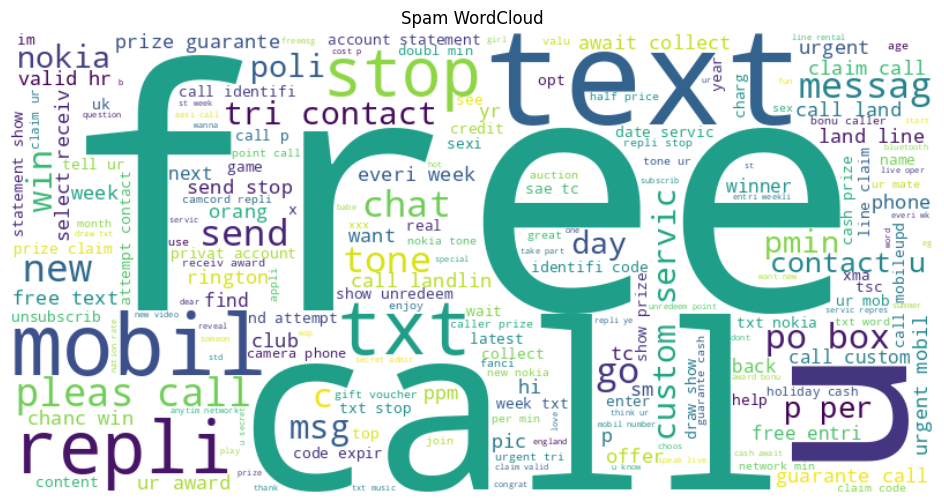

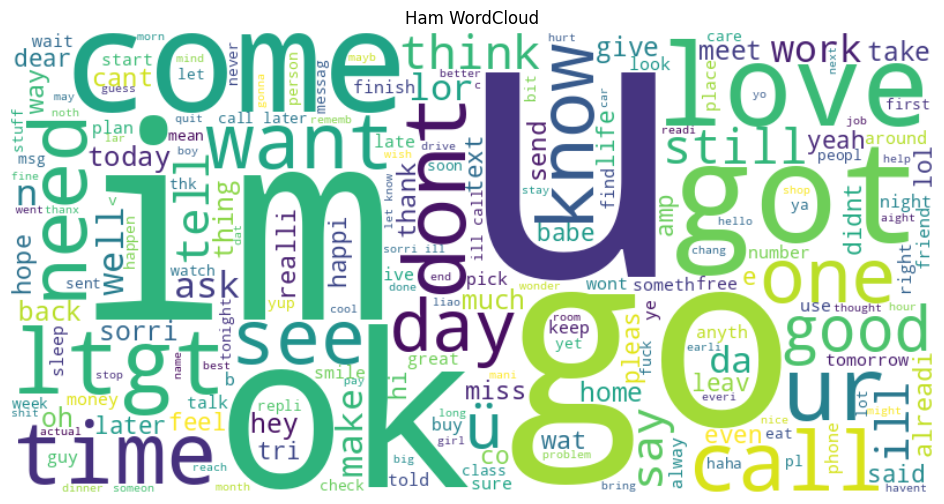


Model Performance:
Accuracy: 0.9659192825112107
Precision: 1.0
Confusion Matrix:
 [[966   0]
 [ 38 111]]

Email: Congratulations! You have won a $1000 gift card. Click here to claim.
Prediction: Spam

Email: Hi John, can we reschedule our meeting for tomorrow?
Prediction: Ham

Email: Get cheap meds now without prescription!
Prediction: Ham

Email: Reminder: Your appointment is scheduled for 10 AM tomorrow.
Prediction: Ham


In [ ]:

!pip install nltk wordcloud --quiet

import pandas as pd
import string, re
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score
from wordcloud import WordCloud
import matplotlib.pyplot as plt


nltk.download('stopwords')
stop_words = set(stopwords.words('english'))
ps = PorterStemmer()


url = "https://raw.githubusercontent.com/justmarkham/pycon-2016-tutorial/master/data/sms.tsv"
data = pd.read_csv(url, sep='\t', names=['label', 'message'])
data['label'] = data['label'].map({'ham': 0, 'spam': 1})

print("Dataset Sample:")
print(data.sample(5))
print("\nClass distribution:\n", data['label'].value_counts())


def clean_text(text):
    text = text.lower()
    text = text.translate(str.maketrans('', '', string.punctuation))
    text = re.sub(r'\d+', '', text)
    words = text.split()
    words = [ps.stem(word) for word in words if word not in stop_words]
    return ' '.join(words)

data['clean_message'] = data['message'].apply(clean_text)
spam_words = ' '.join(data[data['label']==1]['clean_message'])
ham_words = ' '.join(data[data['label']==0]['clean_message'])

plt.figure(figsize=(12,6))
wc_spam = WordCloud(width=800, height=400, background_color='white').generate(spam_words)
plt.imshow(wc_spam, interpolation='bilinear')
plt.axis('off')
plt.title("Spam WordCloud")
plt.show()

plt.figure(figsize=(12,6))
wc_ham = WordCloud(width=800, height=400, background_color='white').generate(ham_words)
plt.imshow(wc_ham, interpolation='bilinear')
plt.axis('off')
plt.title("Ham WordCloud")
plt.show()


X = data['clean_message']
y = data['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

tfidf = TfidfVectorizer(max_features=5000)
X_train_vec = tfidf.fit_transform(X_train)
X_test_vec = tfidf.transform(X_test)


model = MultinomialNB()
model.fit(X_train_vec, y_train)


predictions = model.predict(X_test_vec)
print("\nModel Performance:")
print("Accuracy:", accuracy_score(y_test, predictions))
print("Precision:", precision_score(y_test, predictions))
print("Confusion Matrix:\n", confusion_matrix(y_test, predictions))


sample_emails = [
    "Congratulations! You have won a $1000 gift card. Click here to claim.",
    "Hi John, can we reschedule our meeting for tomorrow?",
    "Get cheap meds now without prescription!",
    "Reminder: Your appointment is scheduled for 10 AM tomorrow."
]

sample_vec = tfidf.transform([clean_text(email) for email in sample_emails])
sample_pred = model.predict(sample_vec)

for email, pred in zip(sample_emails, sample_pred):
    print(f"\nEmail: {email}")
    print("Prediction:", "Spam" if pred else "Ham")
